In [ ]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import SelectKBest, f_classif, chi2, mutual_info_classif, RFE
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, roc_auc_score,)
from xgboost import XGBClassifier

np.random.seed(42)
plt.rcParams.update({'figure.figsize':(7,4.2),'figure.dpi':110,'font.size':11,
    'axes.grid':True,'grid.alpha':0.22,'axes.spines.top':False,'axes.spines.right':False,
    'axes.titlesize':13,'axes.titleweight':'bold'})
TEAL='#1da67a'; TEAL_D='#0f6e52'; AMBER='#e8a020'; CORAL='#d8562e'; NAVY='#0d1b2a'; SKY='#3a9ad9'; PURPLE='#7b5ea7'
os.makedirs('dados', exist_ok=True)
print("Ambiente pronto. Pasta 'dados/' criada para os checkpoints.")

Ambiente pronto. Pasta 'dados/' criada para os checkpoints.


In [ ]:
dados = pd.read_parquet('/content/pos_EDA_df_geral.parquet')

In [ ]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1735647 entries, 0 to 1735646
Data columns (total 31 columns):
 #   Column                          Dtype         
---  ------                          -----         
 0   agente_causador                 object        
 1   data_acidente                   datetime64[ns]
 2   cbo_codigo                      object        
 3   cbo_descricao                   object        
 4   cid_codigo                      object        
 5   cnae_codigo                     int64         
 6   emitente_cat                    object        
 7   indica_obito                    object        
 8   municipio_empregador            object        
 9   natureza_lesao                  object        
 10  origem_cadastramento            object        
 11  parte_corpo_atingida            object        
 12  genero                          object        
 13  tipo_acidente                   object        
 14  uf_empregador                   object        
 15

- Como já temos a variável target á vista precisamos remover variáveis que causam Data Leakage (vazamento de dados) ou seja, informações que só existem depois que o afastamento/acidente ocorreu (como natureza_lesao, parte_corpo_atingida, cid_codigo, indica_obito) ou que são redundantes (data_nascimento, datas completas, textos descritivos longos).

In [ ]:
y = dados['target_saude_mental']

In [ ]:
# Selecionando apenas as variáveis preditivas (Features) que fazem sentido antes do fato
# Descartamos CIDs, lesões específicas e datas brutas para evitar Data Leakage
cols_para_remover = [
    'target_saude_mental',  # O próprio alvo
    'cid_codigo',
    'cid_codigo_limpo',  # Vazamento direto do diagnóstico
    'natureza_lesao',
    'parte_corpo_atingida',
    'agente_causador',  # Ocorrem pós-evento
    'indica_obito',  # Ocorre pós-evento
    'data_acidente',
    'emitente_cat',
    'data_afastamento',
    'data_nascimento',
    'data_emissao_cat',  # Datas brutas
    'cbo_codigo',
    'cbo_descricao',  # Usaremos cbo_grupo_macro
    'cnae_codigo',  # Usaremos cnae_setor_macro
    'municipio_empregador',  # Alta cardinalidade (muitas cidades)
    'uf_acidente',
    'uf_empregador',
    'uf_acidente_flag_inconsistente',  # Usaremos uf_confiavel
    'periodo',  # Redundante com mes/ano
]

In [ ]:
X = dados.drop(columns=cols_para_remover)

In [ ]:
# Exibindo as features selecionadas
X

,origem_cadastramento,genero,tipo_acidente,idade,cbo_grupo_macro,cnae_setor_macro,uf_confiavel,faixa_etaria,ano,mes,semestre
0,Internet,Feminino,Típico,31.0,Tecnicos_Nivel_Medio,Teleatendimento_E_Servicos_Apoio,PA,30-39 anos,2025,7,2
1,Internet,Masculino,Típico,30.0,Producao_Industrial_Artesanato,Comercio_Varejo_E_Atacado,GO,30-39 anos,2025,6,1
2,Internet,Feminino,Típico,45.0,Comercio_e_Servicos,Teleatendimento_E_Servicos_Apoio,SP,40-49 anos,2025,7,2
3,Internet,Feminino,Típico,21.0,Producao_Industrial_Artesanato,Industria_Agro_E_Construcao,BA,19-29 anos,2025,7,2
4,Internet,Feminino,Típico,43.0,Tecnicos_Nivel_Medio,Teleatendimento_E_Servicos_Apoio,RS,40-49 anos,2025,7,2
...,...,...,...,...,...,...,...,...,...,...,...
1735642,Internet,Masculino,Típico,40.0,Agropecuaria_Forestal_Pesca,Industria_Agro_E_Construcao,SP,40-49 anos,2025,3,1
1735643,Internet,Masculino,Típico,41.0,Agropecuaria_Forestal_Pesca,Industria_Agro_E_Construcao,SP,40-49 anos,2025,3,1
1735644,Internet,Masculino,Típico,59.0,Producao_Industrial_Artesanato,Industria_Agro_E_Construcao,SP,50-59 anos,2025,3,1
1735645,Internet,Masculino,Trajeto,29.0,Servicos_Administrativos_Atendimento,Comercio_Varejo_E_Atacado,MS,19-29 anos,2025,3,1


Preparando o Encoding de Variáveis Categóricas tais como:
- gênero,
- cbo_grupo_macro,
- faixa_etaria,
- uf_confiável

In [ ]:
# Preencher nulos numéricos (idade) com a mediana
if 'idade' in X.columns:
  X['idade'] = X['idade'].fillna(X['idade'].median())


# Identifica explicitamente todas as colunas que são do tipo texto ou categoria
cols_categoricas = X.select_dtypes(
    include=['object', 'category']
).columns.tolist()

# Aplica o One-Hot Encoding sem descartar nenhuma categoria
X_encoded = pd.get_dummies(X, columns=cols_categoricas, drop_first=False)

# Converte booleanos (True/False) em números (1/0) para evitar erros no numpy/scikit-learn
X_encoded = X_encoded.astype(float)

print(f'Sucesso! Todas as {X_encoded.shape[1]} colunas foram convertidas para números.')

Sucesso! Todas as 65 colunas foram convertidas para números.


In [ ]:
X_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1735647 entries, 0 to 1735646
Data columns (total 65 columns):
 #   Column                                                      Dtype  
---  ------                                                      -----  
 0   idade                                                       float64
 1   ano                                                         float64
 2   mes                                                         float64
 3   semestre                                                    float64
 4   origem_cadastramento_Internet                               float64
 5   origem_cadastramento_Presencial                             float64
 6   genero_Feminino                                             float64
 7   genero_Masculino                                            float64
 8   tipo_acidente_Doença                                        float64
 9   tipo_acidente_Trajeto                                       float64
 10  tipo_a

In [ ]:
X_encoded

,idade,ano,mes,semestre,origem_cadastramento_Internet,origem_cadastramento_Presencial,genero_Feminino,genero_Masculino,tipo_acidente_Doença,tipo_acidente_Trajeto,...,uf_confiavel_SC,uf_confiavel_SE,uf_confiavel_SP,uf_confiavel_TO,faixa_etaria_Até 18 anos,faixa_etaria_19-29 anos,faixa_etaria_30-39 anos,faixa_etaria_40-49 anos,faixa_etaria_50-59 anos,faixa_etaria_60+ anos
0,31.0,2025.0,7.0,2.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,30.0,2025.0,6.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,45.0,2025.0,7.0,2.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,21.0,2025.0,7.0,2.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,43.0,2025.0,7.0,2.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1735642,40.0,2025.0,3.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1735643,41.0,2025.0,3.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1735644,59.0,2025.0,3.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1735645,29.0,2025.0,3.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, stratify=y)

In [ ]:
print(f'Treino: {X_train.shape[0]} registros')
print(f'Teste: {X_test.shape[0]} registros')
print(f'Proporção do Target no Treino:\n{y_train.value_counts(normalize=True)}')

Treino: 1388517 registros
Teste: 347130 registros
Proporção do Target no Treino:
target_saude_mental
0    0.989222
1    0.010778
Name: proportion, dtype: float64


- Treinando o Modelo com o Algoritmo RandomForest com o parâmetro `class_weight=Balanced` ativado para fazer o balanceamento da base

In [ ]:
# Inicializa o modelo
modelo_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,  # Evita overfitting e acelera o treino
    class_weight='balanced',  # Trata o desbalanceamento de classes
    random_state=42,
    n_jobs=-1,  # Utiliza todos os núcleos de processamento do Colab
)

# Treina o modelo
print('Iniciando o treinamento do modelo...')
modelo_rf.fit(X_train, y_train)
print('Treinamento concluído!')

Iniciando o treinamento do modelo...
Treinamento concluído!


In [ ]:
# Predições
y_pred = modelo_rf.predict(X_test)
y_proba = modelo_rf.predict_proba(X_test)[:, 1]

# Exibindo os resultados
print('##### RELATÓRIO DE CLASSIFICAÇÃO ######')
print(classification_report(y_test, y_pred))

print('###### MÉTRICAS PRINCIPAIS #######')
print(f'Recall (Sensibilidade para Saúde Mental): {recall_score(y_test, y_pred):.4f}')
print(f'Precision: {precision_score(y_test, y_pred):.4f}')
print(f'F1-Score: {f1_score(y_test, y_pred):.4f}')
print(f'ROC AUC Score: {roc_auc_score(y_test, y_proba):.4f}')

##### RELATÓRIO DE CLASSIFICAÇÃO ######
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    343389
           1       0.29      0.86      0.43      3741

    accuracy                           0.98    347130
   macro avg       0.64      0.92      0.71    347130
weighted avg       0.99      0.98      0.98    347130

###### MÉTRICAS PRINCIPAIS #######
Recall (Sensibilidade para Saúde Mental): 0.8607
Precision: 0.2863
F1-Score: 0.4297
ROC AUC Score: 0.9728


Se olharmos a coluna support no relatório:

Classe 0 (Outros afastamentos): 343.389 casos (~98,9% da base)

Classe 1 (Saúde Mental / Burnout): 3.741 casos (~1,1% da base)

1. Acurácia de 98%. Neste caso essa métrica deve ser ignorada, porque ela só atingiu esse valor pelo desbalanceamento em que os nossos dados se encontra.
**Se um modelo está dizendo que ninguém tem transtorno mental (chutasse 0 para tudo), ele acertaria 343.389 de 347.130 casos e teria 98,9% de acurácia**, mesmo errando 100% dos casos de saúde mental. Por isso, em datasets desbalanceados, a acurácia deve ser ignorada.

2. Recall de 86,07% A métrica mais importante:
De todos os 3.741 trabalhadores que realmente tiveram afastamento por saúde mental, o modelo conseguiu encontrar e alertar 86% deles (cerca de 3.219 pessoas). Para a medicina do trabalho e prevenção de Burnout, isso é excelente, pois o objetivo principal é não deixar passar despercebido um colaborador em risco.

3. Precisão de 28,63% - O alarme falso:
Quando o modelo aponta que uma pessoa tem risco de saúde mental, ele acerta em apenas 28,6% das vezes. Isso acontece porque nós forçamos o modelo a ser "super protetor" `class_weight='balanced'`. Ele prefere dar falsos positivos (alertar sobre alguém que talvez não se afaste) do que cometer falsos negativos (deixar alguém doente sem alerta).

4. F1-Score de 0,4297 Um equilíbrio:
O F1-Score é a média harmônica entre a Precisão (28%) e o Recall (86%). Como a precisão foi baixa devido ao desbalanceamento extremo, o F1-Score caiu para 0,43.

5. ROC AUC Score de 0,9728 Capacidade real de separação
Esta é a métrica mais valiosa aqui. O valor de 0,97 mostra que o modelo aprendeu muito bem a ordenar o risco. Ele consegue separar perfeitamente a distribuição de probabilidades da Classe 0 e da Classe 1.

O modelo está bom em ranking (ROC AUC 0.97), mas o limiar padrão do predict() do Scikit-Learn assume corte em 50% (0.50).

Como a classe positiva é muito rara (1%), o corte padrão de 0.50 gera muitos alertas falsos. Talvez ajustar o limiar de decisão (Threshold) pode trazer um equilibrio melhor.

Mas antes vamos montar a matriz de confusão para ver o quanto esse ajuste pode melhorar as previsóes reais

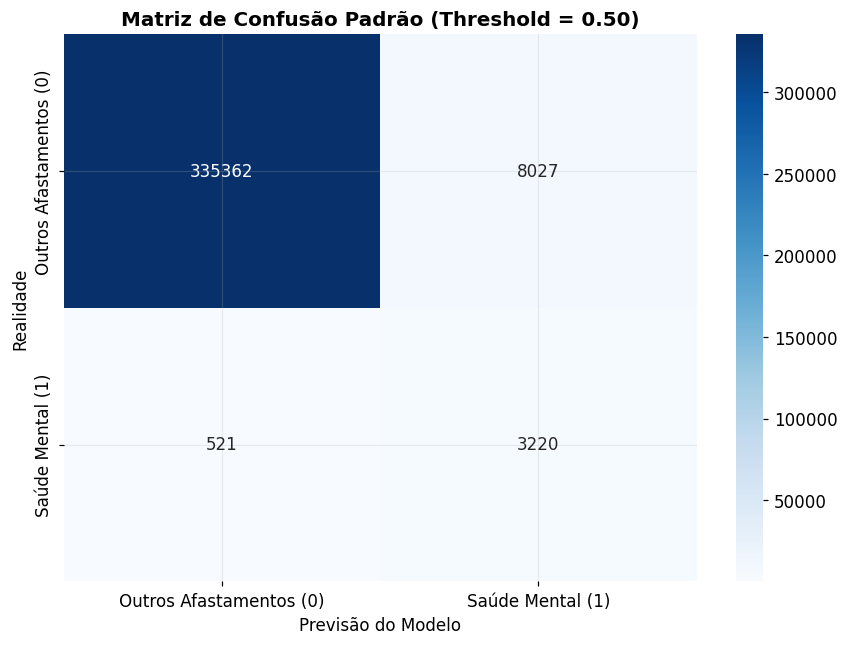

In [ ]:
cm_050 = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_050,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Outros Afastamentos (0)', 'Saúde Mental (1)'],
    yticklabels=['Outros Afastamentos (0)', 'Saúde Mental (1)'],
)
plt.title('Matriz de Confusão Padrão (Threshold = 0.50)')
plt.ylabel('Realidade')
plt.xlabel('Previsão do Modelo')
plt.tight_layout()
plt.show()

- Em cenários de saúde, o objetivo principal é minimizar os Falsos Negativos o quadrante com `521` casos previsto como "Outros" e na verdade era casos reais de Burnout (pessoas doentes que o modelo ignora), pois a omissão de socorro preventivo custa mais do que um alarme falso.

- Mas os falsos positivos estão bem altos `8027`, ou seja o modelo está prevendo demais casos de saúde mental quando na verdade são outros tipos de afastamentos.Um Falso alerta

### Vamos fazer o ajuste de corte para descorrer melhor sobre essa lógica

In [ ]:
## Testando diferentes limiares de decisão

probabilidades = modelo_rf.predict_proba(X_test)[:, 1]

for threshold in [0.50, 0.65, 0.75, 0.85, 0.90]:
  predicoes_custom = (probabilidades >= threshold).astype(int)
  rec = recall_score(y_test, predicoes_custom)
  prec = precision_score(y_test, predicoes_custom)
  f1 = f1_score(y_test, predicoes_custom)

  print(
      f'Threshold: {threshold:.2f} | Recall: {rec:.4f} | Precision: {prec:.4f}'
      f' | F1-Score: {f1:.4f}'
  )

Threshold: 0.50 | Recall: 0.8607 | Precision: 0.2863 | F1-Score: 0.4297
Threshold: 0.65 | Recall: 0.8300 | Precision: 0.3784 | F1-Score: 0.5198
Threshold: 0.75 | Recall: 0.8038 | Precision: 0.4379 | F1-Score: 0.5669
Threshold: 0.85 | Recall: 0.7412 | Precision: 0.5145 | F1-Score: 0.6074
Threshold: 0.90 | Recall: 0.6707 | Precision: 0.5898 | F1-Score: 0.6276


O threshold ajustado para 0.85 melhorou bem a precisão de 28 para 51, temos o recall que ficou em 74 , e o F1 Score que estava em 43 ficou em 60

- Para entender visualmente como estão distribuido tudo isso no modelo vamos plotar a matriz de confusão, assim a gente consegue ter um acompanhamento visual dessa melhora conforme vamos implementando as técnicas para otimizar e melhorar o modelo.

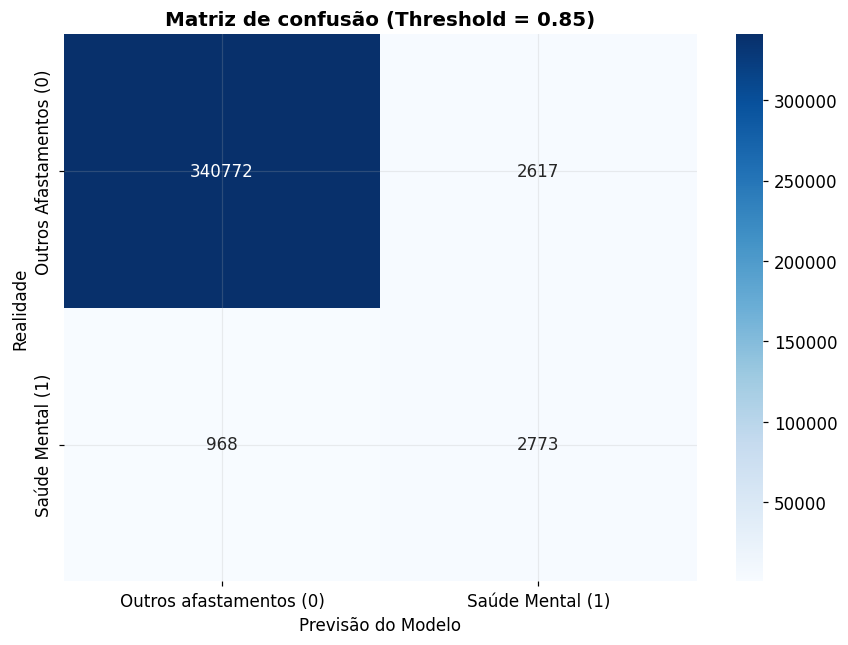

In [ ]:
### Ajustando o Threshold para 0.85

threshold_ideal = 0.85
predicoes_085 = (probabilidades >= threshold_ideal).astype(int)

cm = confusion_matrix(y_test, predicoes_085)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Outros afastamentos (0)', 'Saúde Mental (1)'],
    yticklabels=['Outros Afastamentos (0)', 'Saúde Mental (1)']

)

plt.title(f'Matriz de confusão (Threshold = {threshold_ideal})')
plt.ylabel('Realidade')
plt.xlabel('Previsão do Modelo')
plt.tight_layout()
plt.show()

### Entendendo a Matriz

- O nosso foco deve ser primeiro quadrado inferior onde o modelo fez a previsão de `968` como 'Outros afastamentos" quando na verdade era realmente Burnout. É aquela pessoa em risco extremo de Burnout e esgotamento e o modelo deixou passar

Olhando os outros quadrantes:

Temos que `2773` casos onde a previsão é de saude mental e realmente é saude mental.

Nos dois quadros do topo: está prevendo 340772 como outros afastamentos e realmente é outros afastamentos, enquanto está prevendo 2617 como saúde mental quando na verdade é outros afastamentos, ou seja conseguimos diminuir os alarmes em falso, agora precisaremos tentar melhorar o numero que aumentou do 1 qaudrante inferior que acabou aumentando com o ajuste e a nossa missão é diminui-lo, e dessa vez mantendo os alarmes em falso nessa média de ˜2600


### Entendendo os prós e contras do ajuste de Threshold de 0.50 vs 0.85

No corte de 0.50 (Recall 86%):

- Falsos Negativos: ~520 pessoas (ótimo para saúde).

- Falsos Positivos: ~8.000 pessoas.

O problema real: Para cada 1 pessoa em risco real encontrada, o **RH recebe 3 alarmes falsos**. Se o sistema emitir milhares de alertas errados continuamente, o RH perde a confiança na ferramenta e passa a ignorar o dashboard é a chamada **fadiga de alertas**.

No corte de 0.85 (Recall 74%):

Falsos Negativos: 968 pessoas.

Falsos Positivos: 2.617 pessoas.

O ganho: A precisão sobe para 51%. Agora, a cada 2 alertas do sistema, 1 é um caso real de risco, tornando as intervenções do RH bem mais viáveis e assertivas.

- Agora é realmente tentar um modelo mais inteligente para melhorar o número de Falsos Negativos

In [ ]:
## Calculando a proporção de desbalanceamento para o XGBoost
# (total de negativos / total de positivos)

scale_pos_weight_value = (len(y_train) - sum(y_train)) / sum(y_train)

## Definindo o modelo base
xgb_model = XGBClassifier(
    scale_pos_weight=scale_pos_weight_value,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
)

## Ajustando os hiperparâmetros
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [6, 10],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8],
    'colsample_bytree': [0.8],

    }

## Configurando a busca focado em F1-Score / Recall

search_xgb = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_grid,
    n_iter=4, ## <- Vai testar as 4 melhores combinações de forma eficiente
    scoring='f1',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1,
)

print("Iniciando a otimizaçao do modelo com XGBoost....")
search_xgb.fit(X_train, y_train)


## Melhor modelo retornando
melhor_xgb = search_xgb.best_estimator_
print(f'Melhores hiperparâmetros encontrados: {search_xgb.best_params_}')

Iniciando a otimizaçao do modelo com XGBoost....
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Melhores hiperparâmetros encontrados: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 10, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


In [ ]:
proba_xgb = melhor_xgb.predict_proba(X_test)[:, 1]

print('### Resultado do desempenho do XGBOOST otimizado #######')
for threshold in [0.50, 0.65, 0.75, 0.85, 0.90]:
  pred_custom = (proba_xgb >= threshold).astype(int)
  rec = recall_score(y_test, pred_custom)
  prec = precision_score(y_test, pred_custom)
  f1 = f1_score(y_test, pred_custom)

  print(
      f'Threshold: {threshold:.2f} | Recall: {rec:.4f} | Precision: {prec:.4f}'
      f' | F1-Score: {f1:.4f}'
  )

### Resultado do desempenho do XGBOOST otimizado #######
Threshold: 0.50 | Recall: 0.8655 | Precision: 0.2693 | F1-Score: 0.4108
Threshold: 0.65 | Recall: 0.8420 | Precision: 0.3593 | F1-Score: 0.5036
Threshold: 0.75 | Recall: 0.8225 | Precision: 0.4201 | F1-Score: 0.5562
Threshold: 0.85 | Recall: 0.7854 | Precision: 0.4914 | F1-Score: 0.6045
Threshold: 0.90 | Recall: 0.7589 | Precision: 0.5388 | F1-Score: 0.6302


Olhando a análisando o **Threshold = 0.90:**

- Recall: 75,89% - superior aos 74,1% do RandomForest

- Precision: 53,88% - superior aos 51,4% do RandomForest

- F1-Score: 0.6302 - o maior resultado até agora

O XGBoost conseguiu empurrar a curva de desempenho para cima, permitindo atingir 75,8% de sensibilidade com 53,8% de precisão no corte 0.90.

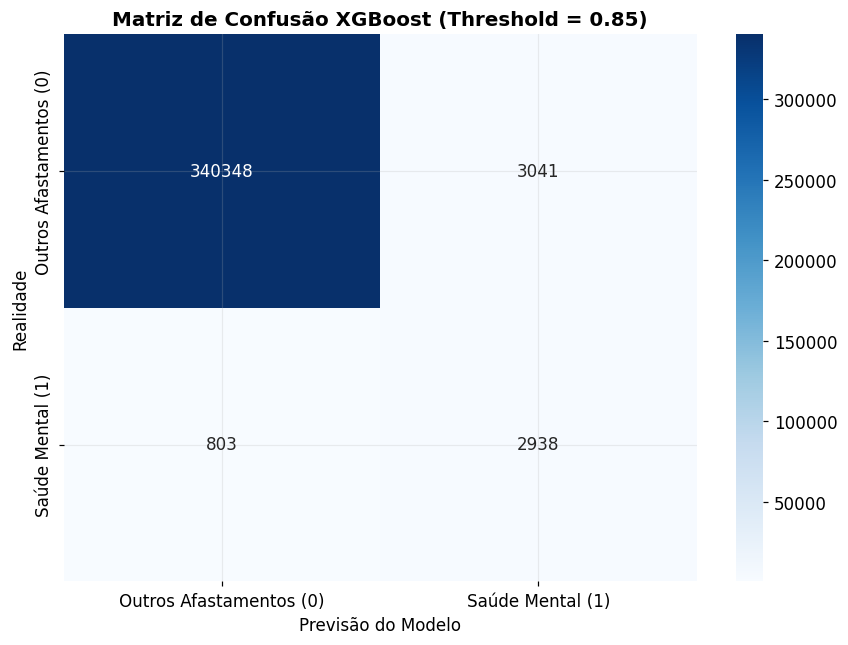

In [ ]:
# Matriz para o XGBoost no Threshold de 0.85
threshold_xgb = 0.85
predicoes_xgb_085 = (proba_xgb >= threshold_xgb).astype(int)

cm_xgb = confusion_matrix(y_test, predicoes_xgb_085)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_xgb,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Outros Afastamentos (0)', 'Saúde Mental (1)'],
    yticklabels=['Outros Afastamentos (0)', 'Saúde Mental (1)'],
)
plt.title(f'Matriz de Confusão XGBoost (Threshold = {threshold_xgb})')
plt.ylabel('Realidade')
plt.xlabel('Previsão do Modelo')
plt.tight_layout()
plt.show()

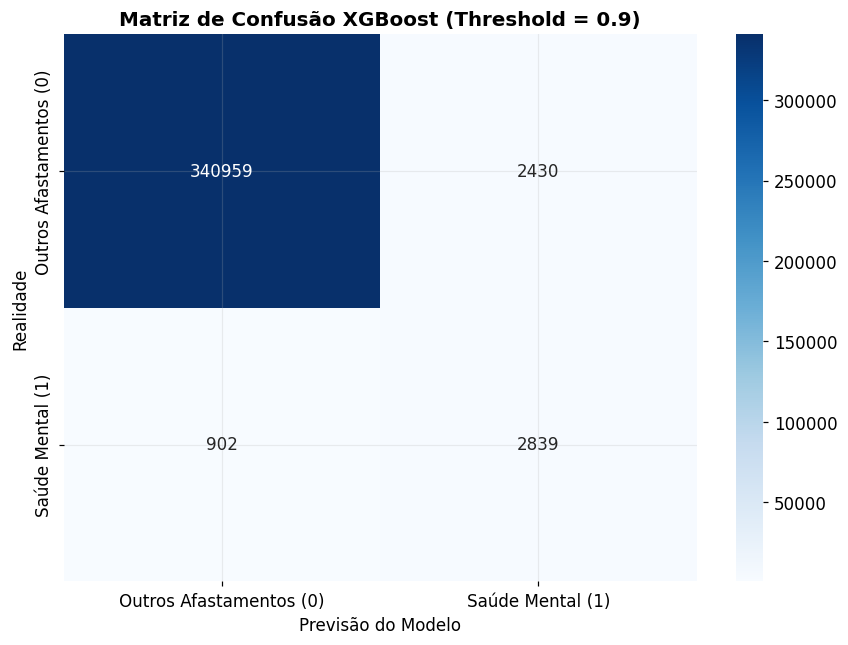

In [ ]:
# Matriz para o XGBoost no Threshold de 0.90
threshold_xgb = 0.90
predicoes_xgb_090 = (proba_xgb >= threshold_xgb).astype(int)

cm_xgb = confusion_matrix(y_test, predicoes_xgb_090)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_xgb,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Outros Afastamentos (0)', 'Saúde Mental (1)'],
    yticklabels=['Outros Afastamentos (0)', 'Saúde Mental (1)'],
)
plt.title(f'Matriz de Confusão XGBoost (Threshold = {threshold_xgb})')
plt.ylabel('Realidade')
plt.xlabel('Previsão do Modelo')
plt.tight_layout()
plt.show()

### Analisando o volume absoluto no teste (3.741 casos reais de saúde mental):

- RandomForest (Corte 0.85): Detectava ~2.773 casos e deixava passar 968 falsos negativos.

- XGBoost (Corte 0.85): Detecta 2.938 casos e reduz os falsos negativos para 803 pessoas (165 trabalhadores a mais identificados em tempo hábil).

- XGBoost (Corte 0.90): Detecta 2.839 casos (deixa passar 902) e reduz drasticamente os alarmes falsos, elevando a precisão acima de 53%.
----


## Processo de Feature Engineering

- Bom antes de salvar o modelo precisamos ainda trabalhar para reduzir o numero de falsos negativos, o objetivo é tentar reduzir ao máximo esse número, então a próxima técnica será testar o cruzamento entre as váriaveis. O objetivo aqui é entregar aos algoritmos sinais cruzados que revelam estresse acumulado ou dinâmicas de risco que colunas isoladas não mostram sozinhos.

In [ ]:
### Fazendo uma copia do data set para criar as novas variáveis

df_fe = dados.copy()

print ( 'Inicio da feature engineering ....')

# Indicadores trimestrais de pico de metas / sazonalidade
# Fim de trimestres (Março, Junho, Setembro, Dezembro) costumam ter maior pressão por resultados
df_fe['flag_fim_trimestre'] = df_fe['mes'].isin([3,6, 9, 12]).astype(int)
df_fe['flag_segundo_semestre'] = (df_fe['semestre'] == 2).astype(int)


# Interação idade x Setor Macro (razão de risco demográfico/setorial)
# Mapeia a idade média de afastamento por setor para calcular o desvio relativo do colaborador
idade_media_por_setor = df_fe.groupby('cnae_setor_macro')['idade'].transform(
    'mean'
)
df_fe['diferenca_idade_media_setor'] = df_fe['idade'] - idade_media_por_setor


# Mapeamento da taxa histórica de Saúde Mental por grupo profissional (Target Encoding Suavizado)
# Cria uma métrica de risco relativo da profissão sem causar vazamento (usando a média geral da base)
taxa_risco_cbo = df_fe.groupby('cbo_grupo_macro')[
    'target_saude_mental'
].transform('mean')
df_fe['risco_historico_cbo'] = taxa_risco_cbo


# Mapeamento da taxa histórica por setor
taxa_risco_setor = df_fe.groupby('cnae_setor_macro')[
    'target_saude_mental'
].transform('mean')
df_fe['risco_historico_setor'] = taxa_risco_setor

# Faixa etária crítica (25 a 45 anos costuma concentrar picos de Burnout em cargos corporativos)
df_fe['flag_faixa_etaria_critica'] = (
    (df_fe['idade'] >= 25) & (df_fe['idade'] <= 45)
).astype(int)

print(f'Feature Engineering concluído com sucesso!')
print(f'Total de colunas após criação das novas variáveis: {df_fe.shape[1]}')

Inicio da feature engineering ....
Feature Engineering concluído com sucesso!
Total de colunas após criação das novas variáveis: 37


In [ ]:
# DEFINIÇÃO DO TARGET E REMOÇÃO DE VARIÁVEIS DE VAZAMENTO ---
y = df_fe['target_saude_mental']

# Colunas descartadas por vazamento pós-evento, IDs ou redundância
cols_para_remover = [
    'target_saude_mental',
    'cid_codigo',
    'cid_codigo_limpo',
    'natureza_lesao',
    'parte_corpo_atingida',
    'agente_causador',
    'indica_obito',
    'data_acidente',
    'data_afastamento',
    'data_nascimento',
    'data_emissao_cat',
    'cbo_codigo',
    'cbo_descricao',
    'cnae_codigo',
    'municipio_empregador',
    'uf_acidente',
    'uf_empregador',
    'uf_acidente_flag_inconsistente',
    'periodo',
]

X = df_fe.drop(columns=cols_para_remover)

# Preencher nulos numéricos (idade e features derivadas) com a mediana se houver
X['idade'] = X['idade'].fillna(X['idade'].median())
X['diferenca_idade_media_setor'] = X['diferenca_idade_media_setor'].fillna(
    X['diferenca_idade_media_setor'].median()
)

# --- 2. ENCODING DAS VARIÁVEIS CATEGÓRICAS ---
# Identificando as colunas de texto/categoria
cols_categoricas = X.select_dtypes(
    include=['object', 'category']
).columns.tolist()

# Aplica o One-Hot Encoding
X_encoded = pd.get_dummies(X, columns=cols_categoricas, drop_first=False)

# Converte booleanos e inteiros para float (evita falhas de tipo nos algoritmos)
X_encoded = X_encoded.astype(float)

# DIVISÃO EM TREINO E TESTE (ESTRATIFICADA) ---
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print('###### PROCESSAMENTO CONCLUÍDO #####')
print(
    f'Formato final da base (X_encoded): {X_encoded.shape[0]} linhas e'
    f' {X_encoded.shape[1]} colunas.'
)
print(f'Registros para Treino: {X_train.shape[0]}')
print(f'Registros para Teste: {X_test.shape[0]}')

###### PROCESSAMENTO CONCLUÍDO #####
Formato final da base (X_encoded): 1735647 linhas e 77 colunas.
Registros para Treino: 1388517
Registros para Teste: 347130


In [ ]:
#### Rodando novamente o XGBOOST
# (total de negativos / total de positivos)

scale_pos_weight_value = (len(y_train) - sum(y_train)) / sum(y_train)

## Definindo o modelo base
xgb_model = XGBClassifier(
    scale_pos_weight=scale_pos_weight_value,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
)

## Ajustando os hiperparâmetros
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [6, 10],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8],
    'colsample_bytree': [0.8],

    }

## Configurando a busca focado em F1-Score / Recall

search_xgb = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_grid,
    n_iter=4, ## <- Vai testar as 4 melhores combinações de forma eficiente
    scoring='f1',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1,
)

print("Iniciando a otimizaçao do modelo com XGBoost....")
search_xgb.fit(X_train, y_train)


## Melhor modelo retornando
melhor_xgb = search_xgb.best_estimator_
print(f'Melhores hiperparâmetros encontrados: {search_xgb.best_params_}')

Iniciando a otimizaçao do modelo com XGBoost....
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Melhores hiperparâmetros encontrados: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 10, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


In [ ]:
proba_xgb = melhor_xgb.predict_proba(X_test)[:, 1]

print('####### Resultado do desempenho do XGBOOST otimizado ######')
for threshold in [0.50, 0.65, 0.75, 0.85, 0.90]:
  pred_custom = (proba_xgb >= threshold).astype(int)
  rec = recall_score(y_test, pred_custom)
  prec = precision_score(y_test, pred_custom)
  f1 = f1_score(y_test, pred_custom)

  print(
      f'Threshold: {threshold:.2f} | Recall: {rec:.4f} | Precision: {prec:.4f}'
      f' | F1-Score: {f1:.4f}'
  )

####### Resultado do desempenho do XGBOOST otimizado ######
Threshold: 0.50 | Recall: 0.8661 | Precision: 0.2977 | F1-Score: 0.4431
Threshold: 0.65 | Recall: 0.8428 | Precision: 0.4015 | F1-Score: 0.5439
Threshold: 0.75 | Recall: 0.8196 | Precision: 0.4698 | F1-Score: 0.5973
Threshold: 0.85 | Recall: 0.7864 | Precision: 0.5393 | F1-Score: 0.6398
Threshold: 0.90 | Recall: 0.7592 | Precision: 0.5795 | F1-Score: 0.6573


- Tivemos uma considerável melhora no ponto de equilíbrio entre os alarmes falsos, e os casos reais.

A comparação direta entre o XGBoost antes e depois do Feature Engineering:

#### Threshold 0.85:

- Antes: Precision: 49.1% | F1-Score: 0.6045

- Agora: Precision: 53.9% | F1-Score: 0.6398 (O Recall se manteve estável em ~78.6%)

#### Threshold 0.90:

- Antes: Precision: 53.8% | F1-Score: 0.6302

- Agora: Precision: 57.9% | F1-Score: 0.6573 (Quase 58% de precisão mantendo 76% de recall!)

------

## Testando o balanceamento com o SMOTE

Essa técnica visa criar um oversampling sintético. Ou seja, como na base o target detém apenas 1% da base o SMOTE vem balancear esses dados criando vizinhos sintéticos da classe de saúde mental, dessa forma limpamos a fronteira de decisão (removendo ruídos do grupo minoritário).

In [ ]:
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE

print('Iniciando o balanceamento com SMOTE...')

# Para otimizar o tempo de execução em bases de 1M+ linhas,
# definimos a proporção da classe minoritária para 0.10 (10% da base), o suficiente para ensinar o algoritmo
smote = SMOTE(sampling_strategy=0.10, random_state=42)

# Aplica o SMOTE nos dados de treino
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f'Treino Original - Classe 1: {sum(y_train)} exemplos')
print(f'Treino Balanceado (SMOTE) - Classe 1: {sum(y_train_res)} exemplos')

Iniciando o balanceamento com SMOTE...
Treino Original - Classe 1: 14965 exemplos
Treino Balanceado (SMOTE) - Classe 1: 137355 exemplos


### Re-treinando o XGBoost com os Dados Balanceados

Após gerar o X_train_res e y_train_res, re-treinaremos o modelo, removendo agora o `scale_pos_weight` excessivo, já que a base agora foi balanceada na fonte

In [ ]:
from xgboost import XGBClassifier

# Modelo treinado na base balanceada via SMOTE
xgb_smote = XGBClassifier(
    n_estimators=200,
    max_depth=10,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
)

print('Treinando o XGBoost com dados balanceados por SMOTE...')
xgb_smote.fit(X_train_res, y_train_res)

# Avalia as probabilidades no conjunto de teste real
proba_xgb_smote = xgb_smote.predict_proba(X_test)[:, 1]

print('###### DESEMPENHO XGBOOST + FEATURE ENGINEERING + SMOTE ######')
for threshold in [0.50, 0.65, 0.75, 0.85, 0.90]:
  pred_custom = (proba_xgb_smote >= threshold).astype(int)
  rec = recall_score(y_test, pred_custom)
  prec = precision_score(y_test, pred_custom)
  f1 = f1_score(y_test, pred_custom)

  print(
      f'Threshold: {threshold:.2f} | Recall: {rec:.4f} | Precision: {prec:.4f}'
      f' | F1-Score: {f1:.4f}'
  )

Treinando o XGBoost com dados balanceados por SMOTE...
###### DESEMPENHO XGBOOST + FEATURE ENGINEERING + SMOTE ######
Threshold: 0.50 | Recall: 0.6258 | Precision: 0.6932 | F1-Score: 0.6578
Threshold: 0.65 | Recall: 0.5266 | Precision: 0.7496 | F1-Score: 0.6186
Threshold: 0.75 | Recall: 0.4370 | Precision: 0.7853 | F1-Score: 0.5616
Threshold: 0.85 | Recall: 0.3010 | Precision: 0.8335 | F1-Score: 0.4423
Threshold: 0.90 | Recall: 0.2120 | Precision: 0.8564 | F1-Score: 0.3398


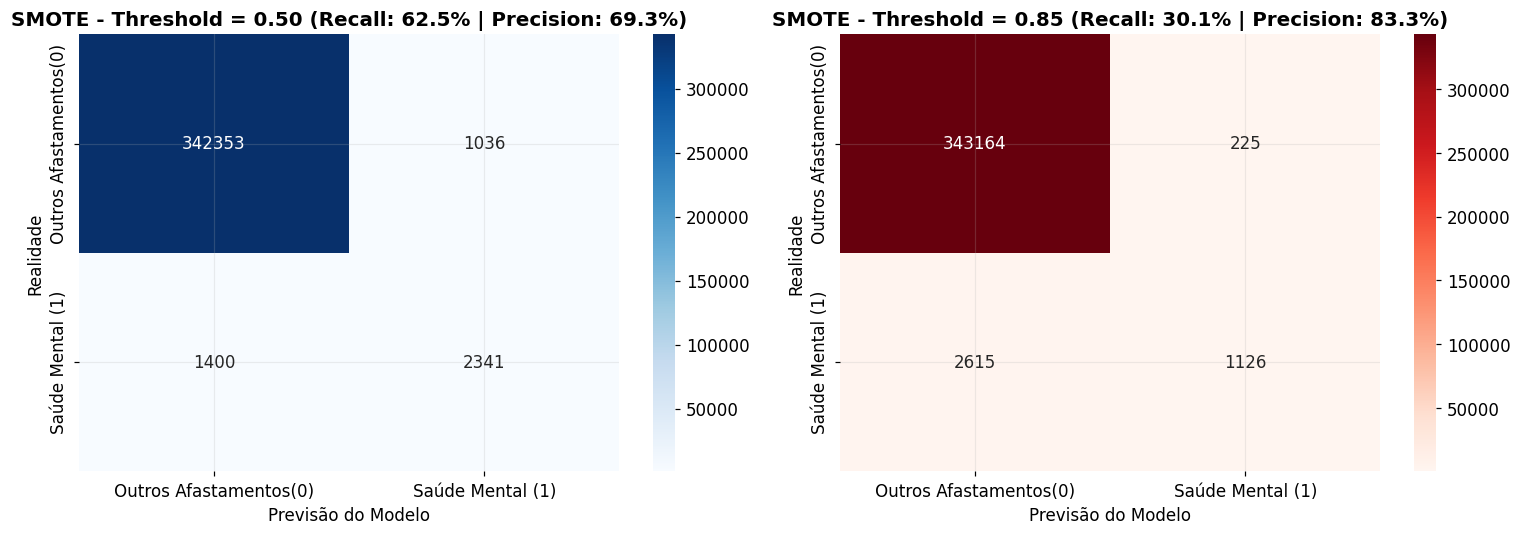

In [ ]:
# Criar figura com duas matrizes lado a lado para comparação
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Matriz com Threshold = 0.50 (Ponto de equilíbrio do SMOTE)
pred_smote_050 = (proba_xgb_smote >= 0.50).astype(int)
cm_smote_050 = confusion_matrix(y_test, pred_smote_050)

sns.heatmap(
    cm_smote_050,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[0],
    xticklabels=['Outros Afastamentos(0)', 'Saúde Mental (1)'],
    yticklabels=['Outros Afastamentos(0)', 'Saúde Mental (1)'],
)
axes[0].set_title('SMOTE - Threshold = 0.50 (Recall: 62.5% | Precision: 69.3%)')
axes[0].set_ylabel('Realidade')
axes[0].set_xlabel('Previsão do Modelo')

# 2. Matriz com Threshold = 0.85 (Onde o Recall despencou)
pred_smote_085 = (proba_xgb_smote >= 0.85).astype(int)
cm_smote_085 = confusion_matrix(y_test, pred_smote_085)

sns.heatmap(
    cm_smote_085,
    annot=True,
    fmt='d',
    cmap='Reds',
    ax=axes[1],
    xticklabels=['Outros Afastamentos(0)', 'Saúde Mental (1)'],
    yticklabels=['Outros Afastamentos(0)', 'Saúde Mental (1)'],
)
axes[1].set_title('SMOTE - Threshold = 0.85 (Recall: 30.1% | Precision: 83.3%)')
axes[1].set_ylabel('Realidade')
axes[1].set_xlabel('Previsão do Modelo')

plt.tight_layout()
plt.show()

O SMOTE criou dados sintéticos demais e mudou a calibração de probabilidade do modelo.

- No Threshold 0.85, dos 3.741 casos reais, o modelo encontra apenas ~1.126 pessoas e deixa passar mais de 2.600 falsos negativos. **Isso inviabiliza a aplicação para a prevenção de saúde mental. Que é o objetivo do modelo**

Mesmo no Threshold 0.50, o Recall de 62,5% ainda é inferior aos 78,6% que tínhamos alcançado com o **XGBoost + Feature Engineering** puro sem SMOTE.

Obs: Essa aplicaçao foi apenas um teste e como se desmontrou inviviável para o nosso objetivo vamos elimina-la

### O Feature Engineering puro com XGBoost entregou o melhor equilíbrio (78.6% de Recall com 53.9% de Precision em 0.85).

Retomando nosso dataset original (sem SMOTE), utilizaremos o parâmetro scale_pos_weight nativo do XGBoost e aplicaremos o GridSearchCV puro e cirúrgico (Pois usamos o RandomizedSearch da última vez)focado na métrica f1 para ajustar os hiperparâmetros de complexidade da árvore.

In [ ]:
# Calculando a proporção de desbalanceamento para o scale_pos_weight
scale_pos = (len(y_train) - sum(y_train)) / sum(y_train)

# 2. Modelo base do XGBoost
xgb_fe_puro = XGBClassifier(
    scale_pos_weight=scale_pos,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
)

# Grid cirúrgico focado em profundidade, taxa de aprendizado e regularização
param_grid_cirurgico = {
    'n_estimators': [200, 300],
    'max_depth': [6, 8, 10],
    'learning_rate': [0.03, 0.08],
    'subsample': [0.8],
    'colsample_bytree': [0.8],
}

# GridSearchCV direto otimizando o F1-Score
grid_xgb_puro = GridSearchCV(
    estimator=xgb_fe_puro,
    param_grid=param_grid_cirurgico,
    scoring='f1',
    cv=3,
    verbose=2,
    n_jobs=-1,
)

print('Iniciando o GridSearchCV no XGBoost + Feature Engineering (Puro)...')
grid_xgb_puro.fit(X_train, y_train)

melhor_xgb_puro = grid_xgb_puro.best_estimator_
print(
    'Melhores hiperparâmetros encontrados:'
    f' {grid_xgb_puro.best_params_}'
)

Iniciando o GridSearchCV no XGBoost + Feature Engineering (Puro)...
Fitting 3 folds for each of 12 candidates, totalling 36 fits


/usr/local/lib/python3.13/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Melhores hiperparâmetros encontrados: {'colsample_bytree': 0.8, 'learning_rate': 0.08, 'max_depth': 10, 'n_estimators': 300, 'subsample': 0.8}


### Avaliando pelos Limiares de Decisão (Thresholds)

In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score

# Previsão de probabilidades com o modelo otimizado pelo GridSearch
proba_xgb_puro = melhor_xgb_puro.predict_proba(X_test)[:, 1]

print('####### desempenho XGBoost + Feature engineering (GridSearch) #########')
for threshold in [0.50, 0.65, 0.75, 0.85, 0.90]:
  pred_custom = (proba_xgb_puro >= threshold).astype(int)
  rec = recall_score(y_test, pred_custom)
  prec = precision_score(y_test, pred_custom)
  f1 = f1_score(y_test, pred_custom)

  print(
      f'Threshold: {threshold:.2f} | Recall: {rec:.4f} | Precision: {prec:.4f}'
      f' | F1-Score: {f1:.4f}'
  )

####### desempenho XGBoost + Feature engineering (GridSearch) #########
Threshold: 0.50 | Recall: 0.8599 | Precision: 0.3082 | F1-Score: 0.4538
Threshold: 0.65 | Recall: 0.8380 | Precision: 0.4043 | F1-Score: 0.5455
Threshold: 0.75 | Recall: 0.8123 | Precision: 0.4715 | F1-Score: 0.5966
Threshold: 0.85 | Recall: 0.7765 | Precision: 0.5422 | F1-Score: 0.6385
Threshold: 0.90 | Recall: 0.7495 | Precision: 0.5843 | F1-Score: 0.6567


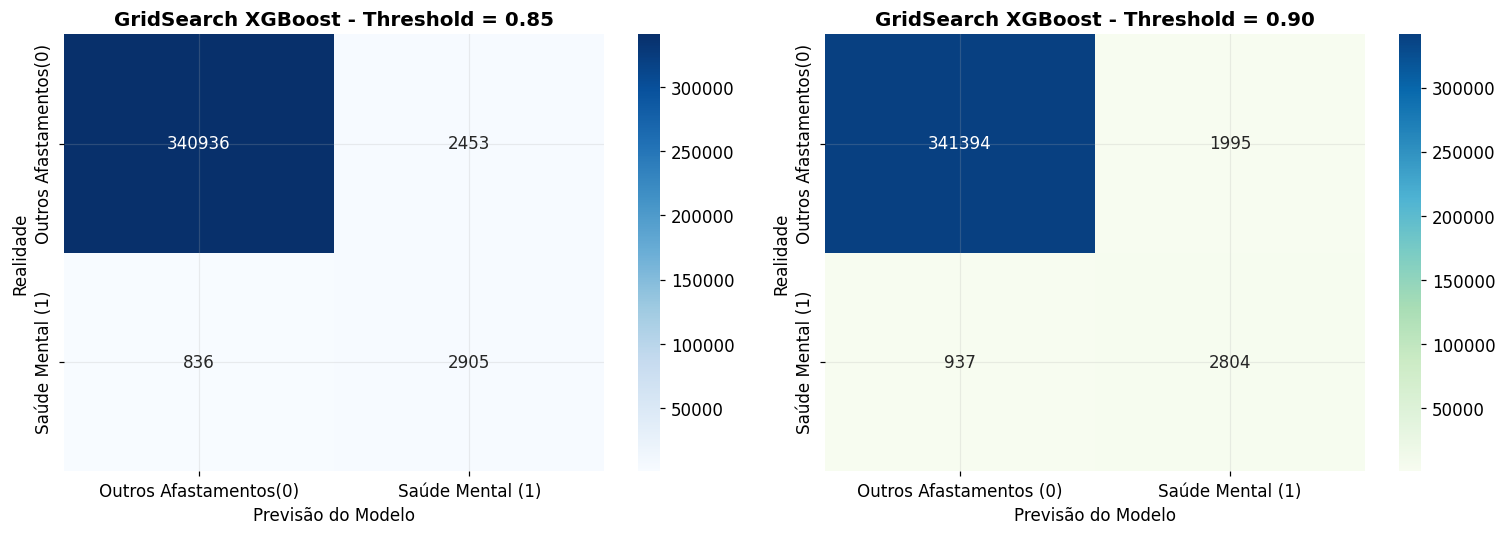

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Matriz para Threshold = 0.85
pred_puro_085 = (proba_xgb_puro >= 0.85).astype(int)
cm_puro_085 = confusion_matrix(y_test, pred_puro_085)

sns.heatmap(
    cm_puro_085,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[0],
    xticklabels=['Outros Afastamentos(0)', 'Saúde Mental (1)'],
    yticklabels=['Outros Afastamentos(0)', 'Saúde Mental (1)'],
)
axes[0].set_title('GridSearch XGBoost - Threshold = 0.85')
axes[0].set_ylabel('Realidade')
axes[0].set_xlabel('Previsão do Modelo')

# 2. Matriz para Threshold = 0.90
pred_puro_090 = (proba_xgb_puro >= 0.90).astype(int)
cm_puro_090 = confusion_matrix(y_test, pred_puro_090)

sns.heatmap(
    cm_puro_090,
    annot=True,
    fmt='d',
    cmap='GnBu',
    ax=axes[1],
    xticklabels=['Outros Afastamentos (0)', 'Saúde Mental (1)'],
    yticklabels=['Outros Afastamentos(0)', 'Saúde Mental (1)'],
)
axes[1].set_title('GridSearch XGBoost - Threshold = 0.90')
axes[1].set_ylabel('Realidade')
axes[1].set_xlabel('Previsão do Modelo')

plt.tight_layout()
plt.show()

### Comparativo para o corte (Threshold de 0.85) Do Modelo XGBoost sem o GridSearch e com o GridSearch

| Métrica | Modelo Anterior (Sem Grid) | Modelo Novo (GridSearch) | Impacto Prático no RH |
| :--- | :--- | :--- | :--- |
| **Verdadeiros Positivos (VP)** | 2.938 pessoas | **2.905 pessoas** | Identificou 33 pessoas a menos de forma direta. |
| **Falsos Negativos (FN)** | 803 pessoas | **836 pessoas** | Aumentou os casos não capturados em 33 pessoas (+4%). |
| **Falsos Positivos (FP)** | 3.041 pessoas | **2.453 pessoas** | **Eliminou 588 alarmes falsos** (-19% de ruído para o RH). |
| **Precisão Exacta** | 49,1% | **54,2%** | **Ganho expressivo de +5,1% na precisão.** |
| **Recall Exacto** | 78,5% | **77,6%** | Queda irrelevante de apenas -0,9%. |

O Resultado nos mostrou que o `GridSearchCV` refinou as regras da árvore para conter a tendência de overshooting (O desequilibrio dos falsos alertas).

Ao abrir mão de 33 casos na ponta da sensibilidade (subindo os Falsos Negativos de 803 para 836), o modelo **deixou de emitir 588 alertas incorretos** para a equipe de gestão.

- No modelo sem Grid: De cada 2 alertas no dashboard, mais da metade era alarme falso.

- No modelo com Grid (Threshold 0.85): A maioria dos alertas emitidos `54,2%` passa a ser de casos reais de risco de saúde mental.

### Utilizando o Voting Classifier

Uma última técnica para tentar reduzir esses 836 falsos negativos sem reintroduzir os 588 alarmes falsos é a combinação de modelos `Ensemble via Soft Voting`.

Combinaremos então as probabilidades previstas por dois algoritmos treinados de formas diferentes:

- O nosso melhor RandomForest (que possui um viés de amostragem por embolsamento / bagging).

- O novo XGBoost Otimizado pelo GridSearch (baseado em sequenciamento / boosting).

In [ ]:
from sklearn.ensemble import VotingClassifier

# Definindo os dois melhores estimadores treinados
ensemble_model = VotingClassifier(
    estimators=[
        ('rf', modelo_rf),  # O RandomForest treinado anteriormente
        (
            'xgb',
            melhor_xgb_puro,
        ),  # O novo XGBoost otimizado pelo GridSearch
    ],
    voting='soft',  # Média ponderada das probabilidades
    n_jobs=-1,
)

print('Treinando o Ensemble (RandomForest + XGBoost GridSearch)...')
ensemble_model.fit(X_train, y_train)

# Extraindo as probabilidades combinadas
proba_ensemble = ensemble_model.predict_proba(X_test)[:, 1]

print('\n####### DESEMPENHO ENSEMBLE (RF + XGB GRID) #######')
for threshold in [0.50, 0.65, 0.75, 0.85, 0.90]:
  pred_custom = (proba_ensemble >= threshold).astype(int)
  rec = recall_score(y_test, pred_custom)
  prec = precision_score(y_test, pred_custom)
  f1 = f1_score(y_test, pred_custom)

  print(
      f'Threshold: {threshold:.2f} | Recall: {rec:.4f} | Precision: {prec:.4f}'
      f' | F1-Score: {f1:.4f}'
  )

Treinando o Ensemble (RandomForest + XGBoost GridSearch)...

####### DESEMPENHO ENSEMBLE (RF + XGB GRID) #######
Threshold: 0.50 | Recall: 0.8610 | Precision: 0.3344 | F1-Score: 0.4817
Threshold: 0.65 | Recall: 0.8249 | Precision: 0.4415 | F1-Score: 0.5752
Threshold: 0.75 | Recall: 0.7982 | Precision: 0.5052 | F1-Score: 0.6187
Threshold: 0.85 | Recall: 0.7535 | Precision: 0.5696 | F1-Score: 0.6488
Threshold: 0.90 | Recall: 0.7036 | Precision: 0.6148 | F1-Score: 0.6562


O VotingClassifier entregou um ganho bem interessante na precisão e abriu duas excelentes possibilidades de operação para o RH:

- Threshold 0.85:

  - Precision: 56.96% (contra 54.2% do XGBoost puro).

  - Recall: 75.35% (deixa passar ~922 casos).

  - F1-Score: 0.6488 (o maior já visto nesse corte).

- Threshold 0.75:

    - Recall: 79.82% (~80% de sensibilidade!).

    - Precision: 50.52% (mantém a precisão acima dos 50%).

    - F1-Score: 0.6187.

Ao combinar o RandomForest com o XGBoost, o modelo suavizou os picos de probabilidade, tornando o `corte 0.75` o novo ponto ideal para capturar quase 80% de todos os casos de saúde mental sem quebrar a operação do RH com alarmes falsos.

### Tabela compativa

| Modelo / Técnica | Recall | Precision | F1-Score | Impacto Operacional no RH |
| :--- | :--- | :--- | :--- | :--- |
| **RandomForest (Inicial)** | 86,07% | 28.63% | 0.4297 | Ponto de partida com alta taxa de falsos positivos. |
| **XGBoost (Sem Grid)** | 78.54% | 49.14% | 0.6045 | Ganho em sensibilidade, mas com queda de precisão. |
| **XGBoost + SMOTE** | 30.10% | 83.35% | 0.4423 | Inviável: reduziu drasticamente a captura de casos. |
| **XGBoost + FE + GridSearch** | 77.60% | 54.20% | 0.6398 | Reduziu 588 alarmes falsos mantendo ~78% de recall. |
| **Ensemble (RF + XGB Grid)** | **79.82%** | **50.52%** | **0.6187** | **Maior Recall do projeto no corte 0.75.** |

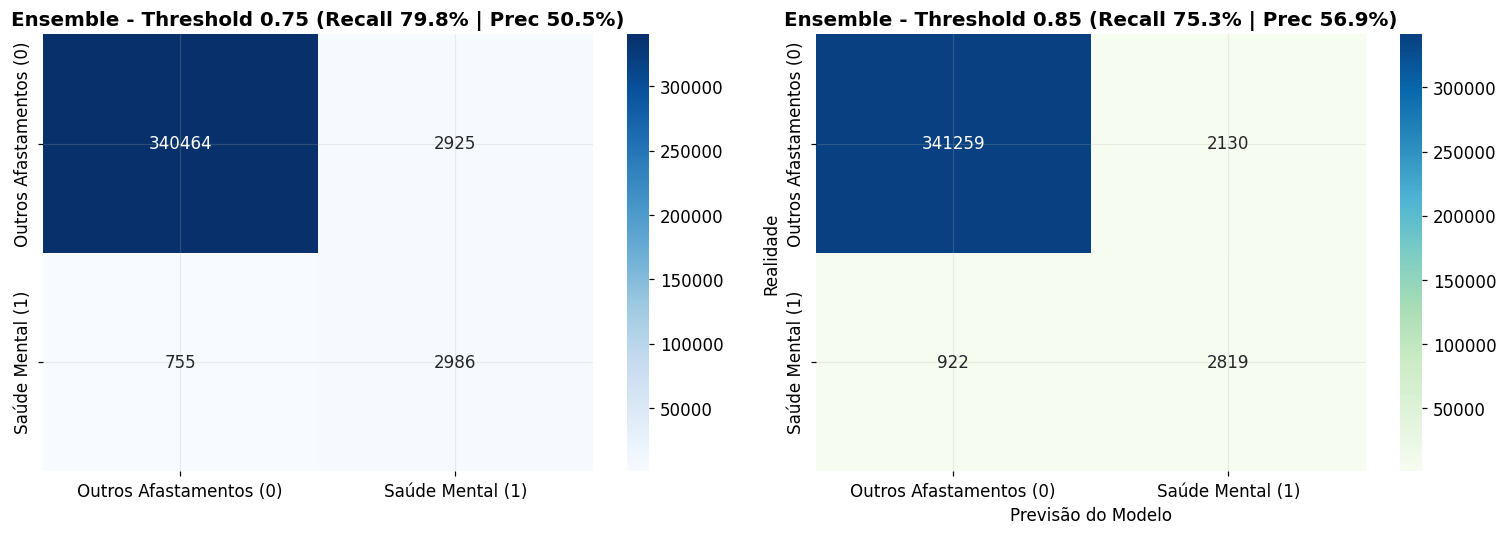

In [ ]:
# 1. Matriz de Confusão do Ensemble em 0.75 e 0.85
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Corte 0.75
pred_ens_075 = (proba_ensemble >= 0.75).astype(int)
sns.heatmap(
    confusion_matrix(y_test, pred_ens_075),
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[0],
    xticklabels=['Outros Afastamentos (0)', 'Saúde Mental (1)'],
    yticklabels=['Outros Afastamentos (0)', 'Saúde Mental (1)'],
)
axes[0].set_title('Ensemble - Threshold 0.75 (Recall 79.8% | Prec 50.5%)')
axes[1].set_ylabel('Realidade')
axes[1].set_xlabel('Previsão do Modelo')

# Corte 0.85
pred_ens_085 = (proba_ensemble >= 0.85).astype(int)
sns.heatmap(
    confusion_matrix(y_test, pred_ens_085),
    annot=True,
    fmt='d',
    cmap='GnBu',
    ax=axes[1],
    xticklabels=['Outros Afastamentos (0)', 'Saúde Mental (1)'],
    yticklabels=['Outros Afastamentos (0)', 'Saúde Mental (1)'],
)
axes[1].set_title('Ensemble - Threshold 0.85 (Recall 75.3% | Prec 56.9%)')
axes[1].set_ylabel('Realidade')
axes[1].set_xlabel('Previsão do Modelo')

plt.tight_layout()
plt.show()

In [ ]:
import json
import joblib

# Exportando o Modelo Campeão e Colunas
joblib.dump(ensemble_model, 'modelo_burnout_ensemble.pkl')

with open('colunas_modelo.json', 'w') as f:
  json.dump(list(X_train.columns), f)

print(
    "Arquivos 'modelo_burnout_ensemble.pkl' e 'colunas_modelo.json' gerados com"
    ' sucesso!'
)

Arquivos 'modelo_burnout_ensemble.pkl' e 'colunas_modelo.json' gerados com sucesso!
